# 03b — Monte Carlo Individual Simulation

Extends the deterministic baseline (03a) by adding stochastic
variation to three inputs:

1. **TSP investment returns** — year-by-year draws from fitted
   normal distributions for each glide-path L Fund
2. **COLA / inflation** — single draw per iteration from
   historical CPI (post-1947), clamped >= 0. The same draw
   drives basic-pay growth during service, the pension COLA,
   and the deflator that expresses results in constant 2026
   dollars.
3. **Life expectancy** — age at death drawn from
   Normal(SSA 2022 MaleTotalAge, 13 yr) conditioned on sep age

BRS and H3 TSP accounts share the same annual return draws so
the TSP balance difference reflects contribution amounts only.
BRS matching begins after 2 years of service (govt 1% auto in
YOS 1–2, 5% total from YOS 3); the member contributes 5% under
both systems.

**TSP data note:** L Fund returns are extended back to 2002 via
synthetic reconstruction (notebook 01, section 4b). Regression
weights (R² > 0.99) applied to individual-fund returns (C, S, I,
F, G) fill pre-inception years. L 2050 gains 10 years (n: 14→24),
which captures the 2001–2002 tech bust and corrects a downward
bias in its standard deviation estimate.

**Inputs:** `data/processed/pay_profiles.csv`,
`data/processed/tsp_returns.csv`,
`data/processed/cpi_inflation.csv`,
`data/processed/life_expectancy.csv`
**Output:** `data/processed/mc_results.csv`


In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.insert(0, str(Path('../src')))
from monte_carlo import (  # noqa: E402
    DEATH_AGE_STD,
    fit_cola_stats,
    fit_fund_stats,
    run_scenario,
)
from utils import percentile_summary  # noqa: E402

PROCESSED = Path('../data/processed')

## Model constants

In [2]:
PROFILES = ['Officer', 'Enlisted', 'PriorEnlistedOfficer']
PROFILE_SCENARIOS = {
    'Officer': list(range(4, 39, 2)),
    'Enlisted': list(range(4, 29, 2)),
    'PriorEnlistedOfficer': list(range(4, 39, 2)),
}
ENTRY_AGE = {
    'Officer': 22,
    'Enlisted': 18,
    'PriorEnlistedOfficer': 18,
}
DISCOUNT_RATE = 0.05
N_ITER = 20_000
SEED_BASE = 42
# Post-WWII; excludes wartime price spikes
CPI_START_YEAR = 1947


## Load data

In [3]:
pay_profiles = pd.read_csv(
    PROCESSED / 'pay_profiles.csv'
)
tsp_returns = pd.read_csv(
    PROCESSED / 'tsp_returns.csv'
)
cpi = pd.read_csv(PROCESSED / 'cpi_inflation.csv')
life_exp = pd.read_csv(
    PROCESSED / 'life_expectancy.csv'
)
det_results = pd.read_csv(
    PROCESSED / 'deterministic_results.csv'
)

cpi_post47 = cpi[cpi['Year'] >= CPI_START_YEAR].copy()
print(f'pay_profiles: {pay_profiles.shape}')
print(f'tsp_returns:  {tsp_returns.shape}')
yr_max = int(cpi_post47['Year'].max())
print(
    f'cpi_post47:   {cpi_post47.shape}'
    f'  (years {CPI_START_YEAR}-{yr_max})'
)
print(f'life_exp:     {life_exp.shape}')

pay_profiles: (110, 3)
tsp_returns:  (39, 21)
cpi_post47:   (79, 3)  (years 1947-2025)
life_exp:     (120, 5)


## Fit stochastic input distributions

In [4]:
fund_stats = fit_fund_stats(tsp_returns)
cola_stats = fit_cola_stats(cpi_post47)

print('TSP L Fund return distributions:')
hdr = '  {:<12} {:>8} {:>8} {:>4}'
print(hdr.format('Fund', 'Mean', 'Std', 'n'))
print('  ' + '-' * 36)
for fund, s in fund_stats.items():
    n = int(tsp_returns[fund].notna().sum())
    mu, sig = s['mean'], s['std']
    print(f'  {fund:<12} {mu:>8.2%} {sig:>8.2%} {n:>4}')

print()
print('COLA distribution (post-1947 CPI):')
c_mu = cola_stats['mean']
c_sig = cola_stats['std']
print(f'  mean = {c_mu:.2%},  std = {c_sig:.2%}')
print(
    f'  DoD actuarial baseline: 2.75%'
    f'  (fitted mean: {c_mu:.2%})'
)
print()
print(
    f'Life expectancy std: {DEATH_AGE_STD:.0f} yr'
    ' (SSA 2022 middle-age approximation)'
)

TSP L Fund return distributions:
  Fund             Mean      Std    n
  ------------------------------------
  L 2050          9.47%   14.87%   24
  L 2040          8.93%   13.79%   24
  L 2030          8.09%   11.89%   24
  L Income        4.80%    3.74%   24

COLA distribution (post-1947 CPI):
  mean = 3.66%,  std = 3.03%
  DoD actuarial baseline: 2.75%  (fitted mean: 3.66%)

Life expectancy std: 13 yr (SSA 2022 middle-age approximation)


## Distribution visualization

Histograms of historical data with fitted normal overlays.
The normal fit is the sampling distribution used in simulation.

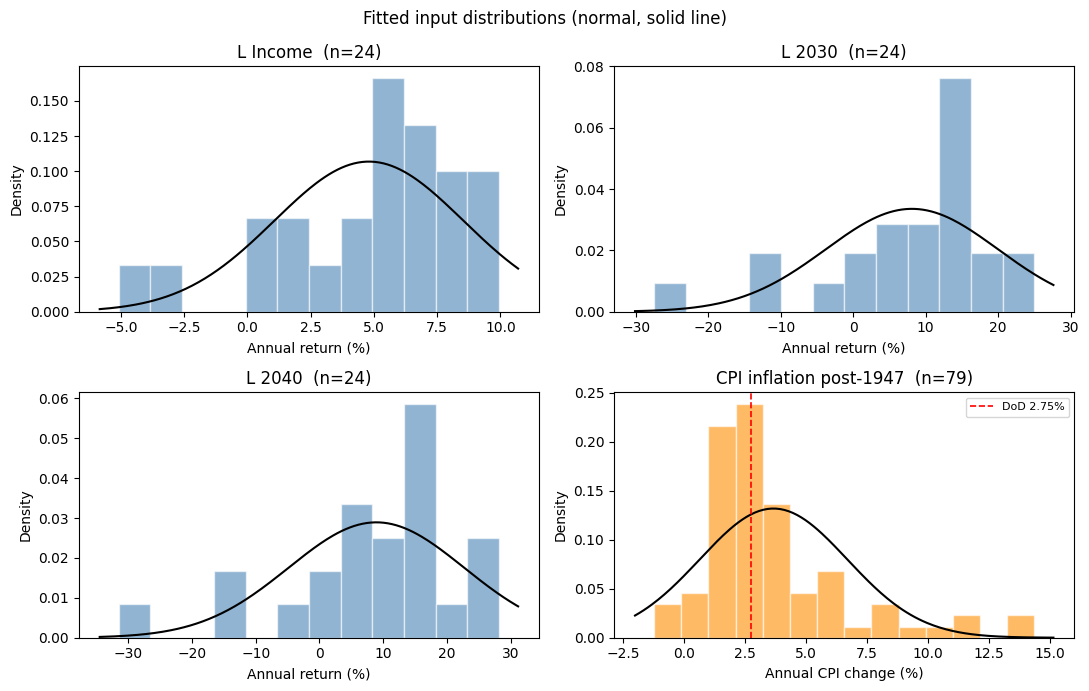

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

plot_funds = ['L Income', 'L 2030', 'L 2040']
for i, fund in enumerate(plot_funds):
    ax = axes.flat[i]
    vals = tsp_returns[fund].dropna().values
    ax.hist(
        vals, bins=12, density=True,
        alpha=0.6, color='steelblue', edgecolor='white',
    )
    xlo, xhi = ax.get_xlim()
    xs = np.linspace(xlo, xhi, 200)
    mu = fund_stats[fund]['mean'] * 100
    sigma = fund_stats[fund]['std'] * 100
    ax.plot(xs, stats.norm.pdf(xs, mu, sigma), 'k-', lw=1.5)
    n_pts = len(vals)
    ax.set_title(f'{fund}  (n={n_pts})')
    ax.set_xlabel('Annual return (%)')

ax = axes.flat[3]
cpi_vals = cpi_post47['Inflation'].dropna().values
ax.hist(
    cpi_vals, bins=14, density=True,
    alpha=0.6, color='darkorange', edgecolor='white',
)
xlo, xhi = ax.get_xlim()
xs = np.linspace(xlo, xhi, 200)
ax.plot(
    xs,
    stats.norm.pdf(xs, c_mu * 100, c_sig * 100),
    'k-', lw=1.5,
)
ax.axvline(2.75, color='red', lw=1.2, ls='--',
           label='DoD 2.75%')
n_cpi = len(cpi_vals)
ax.set_title(
    f'CPI inflation post-{CPI_START_YEAR}  (n={n_cpi})'
)
ax.set_xlabel('Annual CPI change (%)')
ax.legend(fontsize=8)

for ax in axes.flat:
    ax.set_ylabel('Density')

fig.suptitle(
    'Fitted input distributions (normal, solid line)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Convergence testing — Officer, 20 YOS

Monitor stability of mean, median, and 10th/90th percentiles
of the BRS − H3 lifetime value difference as iteration count
grows. Confirms 20,000 iterations is sufficient for stable
percentile estimates.

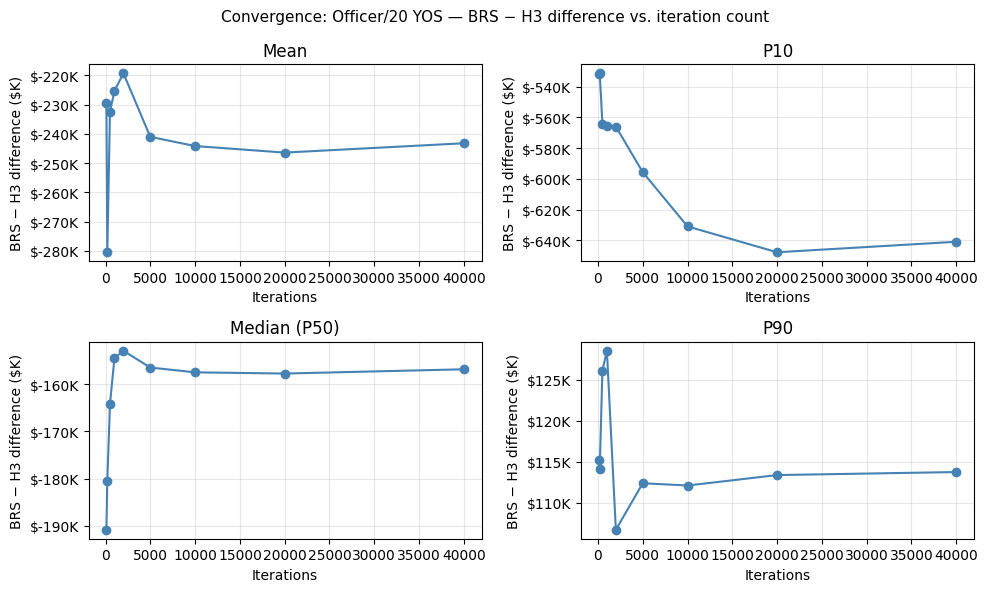

Statistics at 40,000 iterations (Officer/20 YOS):
  mean: $  -243.2K
   p10: $  -641.0K
   p50: $  -156.8K
   p90: $   113.7K


In [6]:
conv_raw = run_scenario(
    'Officer', 20,
    pay_profiles, life_exp,
    fund_stats, cola_stats,
    ENTRY_AGE,
    n_iter=40_000,
    discount_rate=DISCOUNT_RATE,
    seed=SEED_BASE,
)
brs_adv_all = conv_raw['brs_adv']

checkpoints = [
    100, 200, 500, 1_000, 2_000,
    5_000, 10_000, 20_000, 40_000,
]
conv_stats = {}
for n in checkpoints:
    sub = brs_adv_all[:n] / 1000
    conv_stats[n] = {
        'mean': float(sub.mean()),
        'p10':  float(np.percentile(sub, 10)),
        'p50':  float(np.percentile(sub, 50)),
        'p90':  float(np.percentile(sub, 90)),
    }

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
stat_keys = ['mean', 'p10', 'p50', 'p90']
titles = ['Mean', 'P10', 'Median (P50)', 'P90']
for ax, lbl, ttl in zip(axes.flat, stat_keys, titles):
    ys = [conv_stats[n][lbl] for n in checkpoints]
    ax.plot(checkpoints, ys, 'o-', color='steelblue')
    ax.set_title(ttl)
    ax.set_xlabel('Iterations')
    ax.set_ylabel('BRS − H3 difference ($K)')
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'${x:,.0f}K')
    )
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'Convergence: Officer/20 YOS — BRS − H3 difference'
    ' vs. iteration count',
    fontsize=11,
)
plt.tight_layout()
plt.show()

print('Statistics at 40,000 iterations (Officer/20 YOS):')
for k, v in conv_stats[40_000].items():
    print(f'  {k:>4}: ${v:>8,.1f}K')

In [7]:
# Quantitative check: max stat shift from 20K→40K
# expressed as % of P10-P90 spread at N=40K.
# Threshold: any stat that shifts > 1% of spread is unstable.
THRESHOLD_PCT = 1.0

spread_40k = (
    conv_stats[40_000]['p90'] - conv_stats[40_000]['p10']
)
cols = ['p10', 'p50', 'mean', 'p90']
labels = {
    'p10': 'P10', 'p50': 'Median',
    'mean': 'Mean', 'p90': 'P90',
}

print('Half-to-full stability (Officer/20 YOS):')
print(f'P10-P90 spread at N=40K: ${spread_40k:,.1f}K')
print()
print(
    f"  {'Stat':>7}  {'N=20K ($K)':>11}"
    f"  {'N=40K ($K)':>11}  {'Shift ($K)':>10}"
    f"  {'% spread':>9}"
)
print('  ' + '-' * 58)
shifts = {}
for c in cols:
    v20 = conv_stats[20_000][c]
    v40 = conv_stats[40_000][c]
    delta = v40 - v20
    pct = abs(delta) / spread_40k * 100
    shifts[c] = pct
    print(
        f"  {labels[c]:>7}  {v20:>+11.1f}"
        f"  {v40:>+11.1f}  {delta:>+10.1f}"
        f"  {pct:>8.2f}%"
    )

max_pct = max(shifts.values())
worst = labels[max(shifts, key=shifts.get)]
verdict = 'PASS' if max_pct < THRESHOLD_PCT else 'FAIL'
print()
print(
    f'Max shift 20K→40K: {max_pct:.2f}% of spread'
    f' (on {worst})'
)
print(
    f'Stability verdict: {verdict}'
    f' — threshold {THRESHOLD_PCT:.0f}%'
)

Half-to-full stability (Officer/20 YOS):
P10-P90 spread at N=40K: $754.8K

     Stat   N=20K ($K)   N=40K ($K)  Shift ($K)   % spread
  ----------------------------------------------------------
      P10       -647.9       -641.0        +6.8      0.91%
   Median       -157.7       -156.8        +0.9      0.12%
     Mean       -246.4       -243.2        +3.2      0.42%
      P90       +113.4       +113.7        +0.4      0.05%

Max shift 20K→40K: 0.91% of spread (on P10)
Stability verdict: PASS — threshold 1%


## Full Monte Carlo simulation — all 49 scenarios

In [8]:
mc_rows = []
scenario_num = 0
t0 = time.perf_counter()

for profile in PROFILES:
    for sep_yos in PROFILE_SCENARIOS[profile]:
        seed = SEED_BASE + scenario_num * 97
        res = run_scenario(
            profile, sep_yos,
            pay_profiles, life_exp,
            fund_stats, cola_stats,
            ENTRY_AGE,
            n_iter=N_ITER,
            discount_rate=DISCOUNT_RATE,
            seed=seed,
        )
        sep_age = ENTRY_AGE[profile] + sep_yos
        summ = {
            'BRSAdv': percentile_summary(res['brs_adv']),
            'H3Total': percentile_summary(
                res['h3_total']
            ),
            'BRSTotal': percentile_summary(
                res['brs_total']
            ),
        }
        row = {
            'Profile': profile,
            'SepYOS': sep_yos,
            'SepAge': sep_age,
            'N_iter': N_ITER,
        }
        for prefix, s in summ.items():
            for k, v in s.items():
                row[f'{prefix}_{k}'] = v
        mc_rows.append(row)
        scenario_num += 1

elapsed = time.perf_counter() - t0
mc_results = pd.DataFrame(mc_rows)
print(
    f'{len(mc_results)} scenarios, '
    f'{N_ITER:,} iterations each, '
    f'{elapsed:.1f}s'
)
mc_results[
    ['Profile', 'SepYOS', 'BRSAdv_p10',
     'BRSAdv_p50', 'BRSAdv_p90', 'BRSAdv_mean']
].head(10)

49 scenarios, 20,000 iterations each, 1.9s


,Profile,SepYOS,BRSAdv_p10,BRSAdv_p50,BRSAdv_p90,BRSAdv_mean
0,Officer,4,8298.114983,19523.412880,44952.691327,23956.897098
1,Officer,6,16609.380665,37996.776633,84918.312774,46115.308016
2,Officer,8,24919.840022,56326.763592,123520.917439,67591.596487
3,Officer,10,35310.675669,75714.461177,162395.114399,89938.193105
4,Officer,12,45427.117068,96884.061674,206068.470802,114725.230393
5,Officer,14,56245.653924,117439.935041,243120.632504,138361.281091
6,Officer,16,67649.835163,140693.725815,286445.569951,163681.815364
7,Officer,18,80412.822962,163140.306675,330363.299354,189533.736348
8,Officer,20,-627322.544718,-152892.689528,113698.721179,-238386.519033
9,Officer,22,-721646.359422,-175862.173862,132990.932523,-268538.009334


## Percentile summary — lifetime value difference (BRS − H3)

Values in constant 2026 $ thousands. Positive = BRS yields higher lifetime
value; negative = High-Three yields higher lifetime value.

In [9]:
for pct in ['p10', 'p50', 'p90', 'mean']:
    col = f'BRSAdv_{pct}'
    pivot = mc_results.pivot(
        index='Profile',
        columns='SepYOS',
        values=col,
    ).round(0) / 1000
    print(
        f'Lifetime value difference, BRS - H3'
        f' ({pct}), in 2026 $ thousands:'
    )
    print(pivot.to_string())
    print()

Lifetime value difference, BRS - H3 (p10), in 2026 $ thousands:
SepYOS                   4       6       8       10      12      14      16      18       20       22       24       26       28        30        32        34        36        38
Profile                                                                                                                                                                           
Enlisted              4.465   8.991  13.635  18.946  24.677  31.113  37.842  44.834 -425.718 -505.539 -569.802 -596.229 -640.174       NaN       NaN       NaN       NaN       NaN
Officer               8.298  16.609  24.920  35.311  45.427  56.246  67.650  80.413 -627.323 -721.646 -832.252 -863.440 -941.388 -1041.440 -1134.349 -1163.351 -1133.158 -1107.509
PriorEnlistedOfficer  4.594   8.969  13.849  20.628  29.163  38.625  48.821  59.286 -658.478 -657.869 -730.552 -846.305 -843.429  -914.964 -1082.497 -1065.585 -1103.158 -1194.167

Lifetime value difference, BRS - H3 (p50

## Outcome distributions by career length

Shaded bands show P10-P90 (light) and P25-P75 (dark).
Dashed line is the deterministic center-path value (03a).

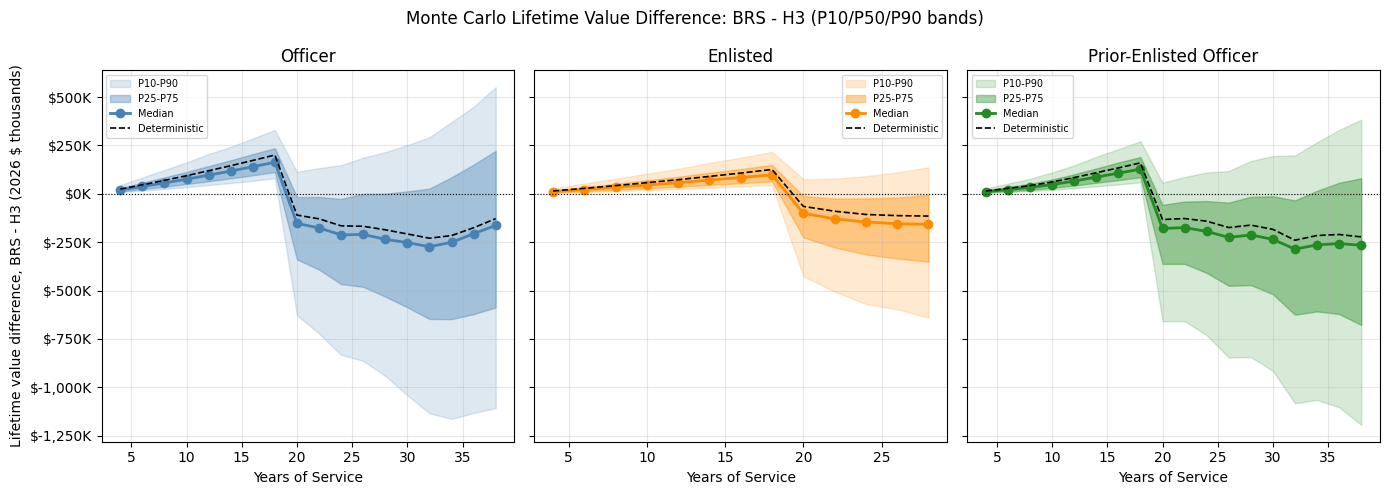

In [10]:
profile_styles = {
    'Officer': ('steelblue', 'Officer'),
    'Enlisted': ('darkorange', 'Enlisted'),
    'PriorEnlistedOfficer': (
        'forestgreen', 'Prior-Enlisted Officer'
    ),
}

fig, axes = plt.subplots(
    1, 3, figsize=(14, 5), sharey=True
)
for ax, (profile, (color, label)) in zip(
    axes, profile_styles.items()
):
    sub = mc_results[mc_results['Profile'] == profile]
    det = det_results[det_results['Profile'] == profile]
    x = sub['SepYOS'].values

    ax.fill_between(
        x,
        sub['BRSAdv_p10'].values / 1000,
        sub['BRSAdv_p90'].values / 1000,
        alpha=0.18, color=color, label='P10-P90',
    )
    ax.fill_between(
        x,
        sub['BRSAdv_p25'].values / 1000,
        sub['BRSAdv_p75'].values / 1000,
        alpha=0.38, color=color, label='P25-P75',
    )
    ax.plot(
        x, sub['BRSAdv_p50'].values / 1000,
        '-o', color=color, lw=2, label='Median',
    )
    ax.plot(
        det['SepYOS'].values,
        det['BRSAdv'].values / 1000,
        'k--', lw=1.2, label='Deterministic',
    )
    ax.axhline(0, color='black', lw=0.8, ls=':')
    ax.set_title(label)
    ax.set_xlabel('Years of Service')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'${x:,.0f}K')
    )

axes[0].set_ylabel(
    'Lifetime value difference, BRS - H3 (2026 $ thousands)'
)
fig.suptitle(
    'Monte Carlo Lifetime Value Difference:'
    ' BRS - H3 (P10/P50/P90 bands)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Comparison to deterministic baseline

MC median vs. deterministic center-path value.
The gap reflects the higher empirical COLA mean (3.66% vs the
2.75% actuarial assumption) plus asymmetry from compounding
variance — Jensen's inequality for TSP returns and for
COLA-driven pay growth — and the truncated life-expectancy and
COLA distributions.


In [11]:
compare = mc_results.merge(
    det_results[['Profile', 'SepYOS', 'BRSAdv']],
    on=['Profile', 'SepYOS'],
)
compare['gap_k'] = (
    compare['BRSAdv'] - compare['BRSAdv_p50']
) / 1000

pivot_gap = compare.pivot(
    index='Profile',
    columns='SepYOS',
    values='gap_k',
).round(1)

print(
    'Deterministic minus MC median ($K)'
    '  [+ = deterministic > MC median]:'
)
print(pivot_gap.to_string())

Deterministic minus MC median ($K)  [+ = deterministic > MC median]:
SepYOS                 4    6     8     10    12    14    16    18    20    22    24    26    28    30    32    34    36    38
Profile                                                                                                                       
Enlisted              3.4  6.4   9.4  12.3  16.0  18.7  23.0  27.3  35.8  39.3  39.1  41.9  42.8   NaN   NaN   NaN   NaN   NaN
Officer               4.8  8.9  13.3  18.0  22.5  28.0  31.9  37.7  43.1  46.7  47.0  42.2  49.3  44.8  43.5  35.1  31.0  35.1
PriorEnlistedOfficer  3.3  6.6   9.7  13.5  17.8  22.5  27.1  32.5  46.0  46.8  52.8  51.0  51.0  51.5  46.1  48.5  46.8  43.3


## Save

In [12]:
out = PROCESSED / 'mc_results.csv'
mc_results.to_csv(out, index=False)
sz = out.stat().st_size / 1024
print(f'Saved: {out.name}  ({sz:.1f} KB)')
print(f'Scenarios: {len(mc_results)}')
print(f'Iterations per scenario: {N_ITER:,}')

Saved: mc_results.csv  (17.4 KB)
Scenarios: 49
Iterations per scenario: 20,000
